# Text classification using Bag-of-words and TF-IDF models


**The bag of words (BOW)** model is a representation that transforms arbitrary text into fixed-length vectors by counting how many times each word appears.

Dataset: https://www.kaggle.com/c/quora-insincere-questions-classification

The goal is to identify what content is toxic in order to improve online communication on the Quora platform.


## Data download and exploration

In [1]:
import pandas as pd
from pathlib import Path
from mlpeople.io.google_drive import download_file_iss

train_file_path = Path('./downloads/quora_train.csv.zip')

# download only if files does NOT exist
if not train_file_path.exists():
    print("Downloading train file...")
    download_file_iss(
        '1710z3YEbLRBvtAJjPXeVtVAaH65UzR8N',
        output_path=str(train_file_path)
    )
else:
    print("Train file already exists. Skipping download.")

In [2]:
# import pandas as pd
# from pathlib import Path
# train_file_path = Path('./quora_train.csv.zip')
raw_df = pd.read_csv(train_file_path)

In [3]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1306122 entries, 0 to 1306121
Data columns (total 3 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   qid            1306122 non-null  object
 1   question_text  1306122 non-null  object
 2   target         1306122 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 29.9+ MB


In [4]:
raw_df.head(10)

,qid,question_text,target
0,00002165364db923c7e6,How did Quebec nationalists see their province...,0
1,000032939017120e6e44,"Do you have an adopted dog, how would you enco...",0
2,0000412ca6e4628ce2cf,Why does velocity affect time? Does velocity a...,0
3,000042bf85aa498cd78e,How did Otto von Guericke used the Magdeburg h...,0
4,0000455dfa3e01eae3af,Can I convert montra helicon D to a mountain b...,0
5,00004f9a462a357c33be,"Is Gaza slowly becoming Auschwitz, Dachau or T...",0
6,00005059a06ee19e11ad,Why does Quora automatically ban conservative ...,0
7,0000559f875832745e2e,Is it crazy if I wash or wipe my groceries off...,0
8,00005bd3426b2d0c8305,"Is there such a thing as dressing moderately, ...",0
9,00006e6928c5df60eacb,Is it just me or have you ever been in this ph...,0


Let's check the data that is not toxic.

In [5]:
sincere_df = raw_df[raw_df.target == 0]
sincere_df.question_text.values[:10]

array(['How did Quebec nationalists see their province as a nation in the 1960s?',
       'Do you have an adopted dog, how would you encourage people to adopt and not shop?',
       'Why does velocity affect time? Does velocity affect space geometry?',
       'How did Otto von Guericke used the Magdeburg hemispheres?',
       'Can I convert montra helicon D to a mountain bike by just changing the tyres?',
       'Is Gaza slowly becoming Auschwitz, Dachau or Treblinka for Palestinians?',
       'Why does Quora automatically ban conservative opinions when reported, but does not do the same for liberal views?',
       'Is it crazy if I wash or wipe my groceries off? Germs are everywhere.',
       'Is there such a thing as dressing moderately, and if so, how is that different than dressing modestly?',
       'Is it just me or have you ever been in this phase wherein you became ignorant to the people you once loved, completely disregarding their feelings/lives so you get to have something g

And now the ones that are toxic.

In [6]:
insincere_df = raw_df[raw_df.target == 1]
insincere_df.question_text.values[:10]

array(['Has the United States become the largest dictatorship in the world?',
       'Which babies are more sweeter to their parents? Dark skin babies or light skin babies?',
       "If blacks support school choice and mandatory sentencing for criminals why don't they vote Republican?",
       'I am gay boy and I love my cousin (boy). He is sexy, but I dont know what to do. He is hot, and I want to see his di**. What should I do?',
       'Which races have the smallest penis?',
       'Why do females find penises ugly?',
       'How do I marry an American woman for a Green Card? How much do they charge?',
       "Why do Europeans say they're the superior race, when in fact it took them over 2,000 years until mid 19th century to surpass China's largest economy?",
       'Did Julius Caesar bring a tyrannosaurus rex on his campaigns to frighten the Celts into submission?',
       "In what manner has Republican backing of 'states rights' been hypocritical and what ways have they actually r

What is the balance of classes in the dataset?

In [8]:
raw_df['target'].value_counts(normalize=True)

target
0    0.93813
1    0.06187
Name: proportion, dtype: float64

### Create a working sample

In [9]:
SHORTEN = True

In [10]:
if SHORTEN:
    SAMPLE_SIZE = 100000
    raw_df = raw_df.sample(SAMPLE_SIZE, random_state=42)
else:
    SAMPLE_SIZE = len(raw_df)

## Text Preprocessing

1. Understanding the bag of words model
2. Understanding the TF-IDF (term frequency - inverted document frequency) model
2. Tokenization
3. Stop word removal
4. Stemming

### Intuition of the Bag of Words (BoW) Text Vectorization Model

1. **Build a dictionary**: Collect all unique words across documents.
2. **Vectorize documents**: Represent each document as word counts from this dictionary (0 if absent).


### Main Problems with Bag of Words (BoW)

1. **High dimensionality**: Many unique words → very large vectors.
2. **Stop words dominance**: Frequent but meaningless words get high weight.
3. **Rare but important words**: Important terms may be underrepresented.
4. **Word forms**: Variants like “go”, “going”, “gone” are treated as different words.


Review examples:

In [11]:
q0 = sincere_df.question_text.values[1]
q0

'Do you have an adopted dog, how would you encourage people to adopt and not shop?'

In [12]:
q1 = raw_df[raw_df.target == 1].question_text.values[0]
q1

'Is Yahoo owned by the Jews?'

### Tokenization

Tokenization splits text into smaller units (tokens) such as words, phrases, or characters.
Example: `"NLP is fun!" → ["NLP", "is", "fun", "!"]`
This structure makes text suitable for NLP processing.

We will use the **Natural Language Toolkit (NLTK)** library.
Link: [https://www.nltk.org/](https://www.nltk.org/)

### Main features of NLTK

1. **Tokenization** – Split text into sentences or words.
2. **Stemming & Lemmatization** – Normalize words to base forms.
3. **Stopword Removal** – Remove frequent, low-value words.
4. **Frequency Analysis** – Count words and n-grams.
5. **POS Tagging** – Identify parts of speech.
6. **NER** – Detect named entities (people, places, etc.).
7. **Parsing** – Build syntax trees of sentences.
8. **Corpora** – Built-in datasets (Brown, Reuters, Movie Reviews, WordNet).
9. **ML for NLP** – Naive Bayes, decision trees for text tasks.
10. **n-grams** – Build and analyze word sequences.
11. **Visualization** – Frequency plots, parse trees.
12. **Integrations** – Works with WordNet, TextBlob, others.

More details in [NLTK Basics - Practical Notebook](https://github.com/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/4_1_nlp_intro/0_1_nltk_basic.ipynb)

### Benefits of NLTK

* **Easy to use** and well documented
* **Large community**
* **Great for learning and teaching NLP**


In [13]:
'NLP is fun!'.replace('!', '').split()

['NLP', 'is', 'fun']

The Punkt Sentence tokenizer breaks text into a list of sentences using an unsupervised algorithm to build a model for acronyms, phrases, and sentence starters. Before use, it must be trained on a large collection of open-source texts in the target language.

In [14]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/maksymstefanko/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

Punkt is smarter than just splitting words by spaces.

In [16]:
from nltk.tokenize import PunktSentenceTokenizer
text = '''
Punkt knows that the periods in Mr.Smith and Johann S. Bach
do not mark sentence boundaries.  And sometimes sentences
can start with non-capitalized words.  i is a good variable
name.
'''
sent_detector = PunktSentenceTokenizer()
print('\n-----\n'.join(sent_detector.tokenize(text.strip())))

Punkt knows that the periods in Mr.Smith and Johann S. Bach
do not mark sentence boundaries.
-----
And sometimes sentences
can start with non-capitalized words.
-----
i is a good variable
name.


But we will tokenize to a word, not a sentence.

Our sentence to tokenize.

In [17]:
q0

'Do you have an adopted dog, how would you encourage people to adopt and not shop?'

After:

In [18]:
word_tokenize(q0)

['Do',
 'you',
 'have',
 'an',
 'adopted',
 'dog',
 ',',
 'how',
 'would',
 'you',
 'encourage',
 'people',
 'to',
 'adopt',
 'and',
 'not',
 'shop',
 '?']

punctuation marks are separated from the word

In [19]:
word_tokenize(' this is (something) with, a lot of, punctuation;')

['this',
 'is',
 '(',
 'something',
 ')',
 'with',
 ',',
 'a',
 'lot',
 'of',
 ',',
 'punctuation',
 ';']

In [20]:
q1

'Is Yahoo owned by the Jews?'

In [21]:
word_tokenize(q1)

['Is', 'Yahoo', 'owned', 'by', 'the', 'Jews', '?']

In [23]:
q0_tok = word_tokenize(q0)
q1_tok = word_tokenize(q1)

### Stopword Removal

**Stopwords** are frequent words with little semantic value (e.g., “and”, “or”, “in”, “to”, “he”, “she”).

In NLP, they are often removed to reduce data size and help models focus on more meaningful terms for tasks like classification, sentiment analysis, and information retrieval.


In [24]:
q1_tok

['Is', 'Yahoo', 'owned', 'by', 'the', 'Jews', '?']

In [26]:
from nltk.corpus import stopwords

nltk.download('stopwords')

english_stopwords = stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/maksymstefanko/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


review the list of stop words:

In [27]:
", ".join(english_stopwords)

"a, about, above, after, again, against, ain, all, am, an, and, any, are, aren, aren't, as, at, be, because, been, before, being, below, between, both, but, by, can, couldn, couldn't, d, did, didn, didn't, do, does, doesn, doesn't, doing, don, don't, down, during, each, few, for, from, further, had, hadn, hadn't, has, hasn, hasn't, have, haven, haven't, having, he, he'd, he'll, her, here, hers, herself, he's, him, himself, his, how, i, i'd, if, i'll, i'm, in, into, is, isn, isn't, it, it'd, it'll, it's, its, itself, i've, just, ll, m, ma, me, mightn, mightn't, more, most, mustn, mustn't, my, myself, needn, needn't, no, nor, not, now, o, of, off, on, once, only, or, other, our, ours, ourselves, out, over, own, re, s, same, shan, shan't, she, she'd, she'll, she's, should, shouldn, shouldn't, should've, so, some, such, t, than, that, that'll, the, their, theirs, them, themselves, then, there, these, they, they'd, they'll, they're, they've, this, those, through, to, too, under, until, up, 

Function to remove stop words:

In [28]:
def remove_stopwords(tokens):
    return [word for word in tokens if word.lower() not in english_stopwords]

In [30]:
q0_stp = remove_stopwords(q0_tok)

q0_tok, q0_stp

(['Do',
  'you',
  'have',
  'an',
  'adopted',
  'dog',
  ',',
  'how',
  'would',
  'you',
  'encourage',
  'people',
  'to',
  'adopt',
  'and',
  'not',
  'shop',
  '?'],
 ['adopted', 'dog', ',', 'would', 'encourage', 'people', 'adopt', 'shop', '?'])

In [31]:
q1_stp = remove_stopwords(q1_tok)

q1_tok, q1_stp

(['Is', 'Yahoo', 'owned', 'by', 'the', 'Jews', '?'],
 ['Yahoo', 'owned', 'Jews', '?'])

### Stemming

**Stemming** reduces words to a base form by removing suffixes or prefixes.
Examples:

* “go”, “gone”, “going” → “go”
* “birds”, “bird” → “bird”

It is rule-based and less precise, sometimes producing non-existent stems (e.g., “univers”).


In [32]:
from nltk.stem.snowball import SnowballStemmer

stemmer = SnowballStemmer(language='english')
stemmer.stem('going')

'go'

In [33]:
stemmer.stem('supposedly')

'suppos'

In [34]:
def stem(tokens):
    return [stemmer.stem(word) for word in tokens]

In [35]:
q0_stm = stem(q0_stp)
q0_stp, q0_stm

(['adopted', 'dog', ',', 'would', 'encourage', 'people', 'adopt', 'shop', '?'],
 ['adopt', 'dog', ',', 'would', 'encourag', 'peopl', 'adopt', 'shop', '?'])

In [36]:
q1_stm = stem(q1_stp)
q1_stp, q1_stm

(['Yahoo', 'owned', 'Jews', '?'], ['yahoo', 'own', 'jew', '?'])

### Lemmatization

**Lemmatization** converts a word to its dictionary base form using grammar and context.
Example: “better” → “good”.

It is more accurate than stemming but also more computationally intensive. The choice between them depends on the task and experimentation.

Examples:

* “love” → “love”
* “loving” → “love”
* “lovable” → “love”


## Bag of Words Implementation
How we can implement bag of words vectorization ourselves:

1. Create a dictionary using Count Vectorizer
2. Convert text to vectors using Count Vectorizer
3. Configure text preprocessing in Count Vectorizer

### Creating a dictionary

In [37]:
raw_df.question_text.values

array(['What is the most effective classroom management skill/technique to create a good learning environment?',
       'Can I study abroad after 10th class from Bangladesh?',
       'How can I make friends as a college junior?', ...,
       'What are some services that will let you quickly separate parts of a video at the five minute and ten minute mark into two separate videos?',
       'What credit card processors do online marketplaces use?',
       'On which number system does a computer work?'],
      shape=(100000,), dtype=object)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# use all default params here
raw_vect = CountVectorizer()
raw_vect_fit = raw_vect.fit(raw_df.question_text)
raw_vect.get_feature_names_out()[10000:10010]

array(['cleaved', 'cleaveland', 'cleaver', 'cleen', 'clefs', 'cleft',
       'clemency', 'clemente', 'clementines', 'clemmensen'], dtype=object)

In [39]:
raw_vect.get_feature_names_out()[:10]

array(['00', '000', '0000', '00000001', '0005', '000501', '000czk', '001',
       '003', '003a'], dtype=object)

### Converting documents to vectors

In [40]:
%%time
vectors = raw_vect.transform(raw_df.question_text)

CPU times: user 414 ms, sys: 61.7 ms, total: 476 ms
Wall time: 535 ms


In [41]:
vectors

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1155416 stored elements and shape (100000, 51543)>

In [42]:
raw_df.question_text.values[0]

'What is the most effective classroom management skill/technique to create a good learning environment?'

In [50]:
vectors[0].toarray()[0][2000:2100], set(vectors[0].toarray()[0])

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 {np.int64(0), np.int64(1)})

### Setting Count Vectorizer parameters

In [51]:
stemmer = SnowballStemmer(language='english')

def tokenize(text):
    return [stemmer.stem(word) for word in word_tokenize(text)]

In [52]:
tokenize('What is the really (dealing) here?')

['what', 'is', 'the', 'realli', '(', 'deal', ')', 'here', '?']

In [53]:
vectorizer = CountVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    stop_words=english_stopwords,
    max_features=1000
)

In [54]:
%%time
vectorizer.fit(raw_df.question_text)

/opt/miniconda3/envs/mlpeople5/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/miniconda3/envs/mlpeople5/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'m", "'s", 'abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', "n't", 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(


CPU times: user 10 s, sys: 168 ms, total: 10.2 s
Wall time: 11 s


,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",<function tok...t 0x30a08b9c0>
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.","['a', 'about', ...]"
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",

In [55]:
len(vectorizer.vocabulary_)

1000

In [56]:
vectorizer.get_feature_names_out()[:100]

array(['!', '$', '%', '&', "'", "''", "'m", "'s", '(', ')', ',', '-', '.',
       '1', '10', '100', '12', '12th', '15', '2', '20', '2017', '2018',
       '3', '30', '4', '5', '6', '7', '8', ':', '?', '[', ']', '``',
       'abl', 'abroad', 'abus', 'accept', 'access', 'accomplish',
       'accord', 'account', 'achiev', 'act', 'action', 'activ', 'actor',
       'actual', 'ad', 'add', 'address', 'admiss', 'adult', 'advanc',
       'advantag', 'advic', 'affect', 'africa', 'african', 'age', 'agre',
       'air', 'allow', 'almost', 'alon', 'alreadi', 'also', 'altern',
       'alway', 'amazon', 'america', 'american', 'amount', 'analysi',
       'android', 'ani', 'anim', 'anoth', 'answer', 'anxieti', 'anyon',
       'anyth', 'apart', 'app', 'appear', 'appl', 'appli', 'applic',
       'approach', 'arab', 'area', 'armi', 'around', 'art', 'asian',
       'ask', 'associ', 'atheist', 'attack'], dtype=object)

In [57]:
%%time
inputs = vectorizer.transform(raw_df.question_text)

CPU times: user 9.97 s, sys: 219 ms, total: 10.2 s
Wall time: 10.5 s


In [58]:
inputs.shape

(100000, 1000)

In [59]:
raw_df.question_text.values[0]

'What is the most effective classroom management skill/technique to create a good learning environment?'

In [60]:
inputs[0].toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

To transform the test set, we could run the following code:

In [ ]:
%%time
# test_inputs = vectorizer.transform(test_df.question_text)

## Training a ML model for text classification

Plan:

- Create training and validation sets
- Train a logistic regression model
- Make predictions on training, validation, and test data

### Splitting into training and validation sets

In [61]:
from sklearn.model_selection import train_test_split

train_inputs, val_inputs, train_targets, val_targets = train_test_split(
    inputs,
    raw_df.target,
    test_size=0.3,
    random_state=42
)

train_inputs.shape, train_targets.shape, val_inputs.shape, val_targets.shape

((70000, 1000), (70000,), (30000, 1000), (30000,))

### Training a logistic regression model

In [62]:
from sklearn.linear_model import LogisticRegression

MAX_ITER = 1000

model = LogisticRegression(max_iter=MAX_ITER, solver='sag')

In [63]:
%%time
model.fit(train_inputs, train_targets)

CPU times: user 4.27 s, sys: 42.2 ms, total: 4.31 s
Wall time: 4.47 s


/opt/miniconda3/envs/mlpeople5/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Make predictions using a model

In [65]:
train_preds = model.predict(train_inputs)
pd.Series(train_preds).value_counts(), pd.Series(train_targets).value_counts()

(0    67952
 1     2048
 Name: count, dtype: int64,
 target
 0    65784
 1     4216
 Name: count, dtype: int64)

In [66]:
from sklearn.metrics import accuracy_score, f1_score

accuracy_score(train_targets, train_preds), f1_score(train_targets, train_preds)

(0.9504285714285714, 0.44604086845466157)

Compare this to the primitive model, which says that every phrase is ecological (target=0):

In [67]:
import numpy as np

accuracy_score(train_targets, np.zeros(len(train_targets))), f1_score(train_targets, np.zeros(len(train_targets)))


(0.9397714285714286, 0.0)

Compare this to the primitive model, which says that random 6% of phrase is toxic (target=1):

In [68]:
n = len(train_targets)

# start with all zeros
preds = np.zeros(n, dtype=int)

# choose 6% random indices to flip to 1
rng = np.random.default_rng(seed=42)  # optional seed for reproducibility
ones_idx = rng.choice(n, size=int(0.06 * n), replace=False)
preds[ones_idx] = 1

accuracy_score(train_targets, preds), f1_score(train_targets, preds)

(0.8873714285714286, 0.06321292775665399)

### How to get predictions on new data?

transform the data with a trained vectorizer and pass it to the model.

In [69]:
model.predict(vectorizer.transform(sincere_df.question_text.values[:10]))

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [70]:
model.predict_proba(vectorizer.transform(sincere_df.question_text.values[:10]))[:,1].round(2)

array([0.07, 0.1 , 0.  , 0.02, 0.03, 0.04, 0.91, 0.04, 0.01, 0.02])

In [72]:
model.predict(vectorizer.transform(insincere_df.question_text.values[:10])), insincere_df.target.values[:10]

(array([0, 0, 1, 1, 0, 0, 0, 1, 0, 0]), array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))

## Error analysis

In [74]:
raw_df['prediction'] = model.predict(inputs)
raw_df.shape

(100000, 4)

In [75]:
from sklearn.metrics import confusion_matrix

confusion_matrix(raw_df.target, raw_df.prediction)

array([[92983,   979],
       [ 4088,  1950]])

In [77]:
raw_df['prediction_proba'] = model.predict_proba(inputs)[:, 1]
raw_df.target.value_counts()

target
0    93962
1     6038
Name: count, dtype: int64

<Axes: >

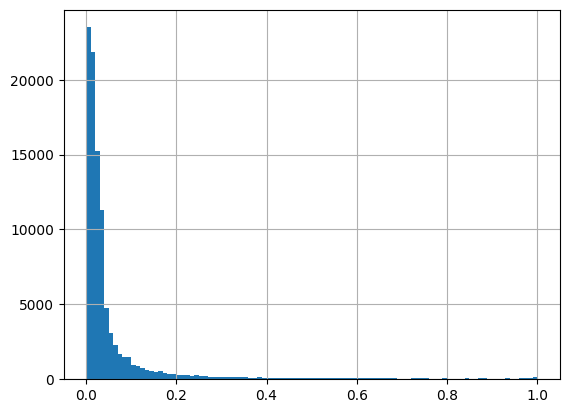

In [78]:
raw_df.prediction_proba.hist(bins=100)

shift the classification threshold to 0.1-0.2 and if this would improve F1.

In [79]:
raw_df['prediction_0.2'] = raw_df.prediction_proba > 0.2
f1_score(raw_df.target, raw_df['prediction_0.2'])

0.5158121884068755

In [80]:
confusion_matrix(raw_df.target, raw_df['prediction_0.2'])

array([[90027,  3935],
       [ 2572,  3466]])

Examine separately the questions in which we make false positive and false negative predictions.

In [81]:
raw_df['error'] = raw_df.target != raw_df['prediction_0.2']

False negative results can be obtained as follows:

In [82]:
raw_df[raw_df.error & raw_df.target==1]

,qid,question_text,target,prediction,prediction_proba,prediction_0.2,error
691951,8786fa2e795d2d0e1440,Is Yahoo owned by the Jews?,1,0,0.168113,False,True
1057714,cf41b3cc824bdc767b4b,"If Macedonia is supposedly ""purely"" Greek and ...",1,0,0.027521,False,True
30882,0609338dee541a017b5f,Could the numerous acts of arms being severed ...,1,0,0.025897,False,True
908188,b1f5208e0f44556a5964,Should plus-size women wear dresses and skirts...,1,0,0.124548,False,True
933912,b704f07087d87705b434,Why do we constantly get questions from gun-gr...,1,0,0.141734,False,True
...,...,...,...,...,...,...,...
840664,a4c0771befc0fdb5204c,It is not strange that there wasn’t any attemp...,1,0,0.197522,False,True
709348,8adf3b4c5f39625a1ed1,What was the real reason for Jesus to quit the...,1,0,0.004365,False,True
596632,74db98e51a653f6927c6,Is Astrologer R K Shastri Fraud?,1,0,0.031452,False,True
938680,b7f526728f983ee04683,Why do Sikhs hate Hindus?,1,0,0.150058,False,True


It would also be useful to do a feature importance analysis here. Words like `black`, `white`, `jews` are likely to contribute well to predicting that the question is non-ecological.

In [83]:
feature_importance = pd.Series(model.coef_[0], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance

liber      2.476087
rape       2.372808
muslim     2.288609
obama      2.228775
atheist    1.908934
             ...   
food      -1.149806
appli     -1.222626
affect    -1.252458
2017      -1.425182
?         -2.339489
Name: imp, Length: 1000, dtype: float64

In [84]:
feature_importance[:10]

liber       2.476087
rape        2.372808
muslim      2.288609
obama       2.228775
atheist     1.908934
sister      1.844742
democrat    1.833307
jew         1.828285
trump       1.801411
gay         1.790034
Name: imp, dtype: float64

The hypothesis is confirmed and so you can understand why your model makes certain predictions.

Conversely, these words reduce the likelihood that the issue is unecological/toxic:

In [85]:
feature_importance[-10:]

situat    -1.016029
tv        -1.027969
refer     -1.044800
account   -1.051570
career    -1.105109
food      -1.149806
appli     -1.222626
affect    -1.252458
2017      -1.425182
?         -2.339489
Name: imp, dtype: float64

## TF-IDF

TF-IDF (Term Frequency–Inverse Document Frequency) measures how important a word is in a document relative to a corpus.

### How it works

1. **TF** – How often a word appears in a document.
2. **IDF** – How rare the word is across all documents (rarer → higher weight).
3. **TF-IDF** – Highlights words frequent in one document but rare in others.

![](https://miro.medium.com/v2/resize\:fit:816/1*Cp46FtVZPkQANjdwmwr3fg.jpeg)

TF-IDF reduces the impact of common words and emphasizes meaningful terms.

Example calculation:
![](https://media.licdn.com/dms/image/D4D12AQF8sI1V68UsIQ/article-cover_image-shrink_600_2000/0/1677509695129?e=2147483647\&v=beta\&t=pDHLFUdBEFMD3q6K0eNgg_C_zPYYYxikomIN00cfTuo)


In [86]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Our documents (texts)
documents = [
    "the machine works very well",
    "the machine and the person work together",
    "the person drives the machine"
]

# Create an object for calculating TF-IDF
vectorizer = TfidfVectorizer()

# Calculate TF-IDF for our documents
tfidf_matrix = vectorizer.fit_transform(documents)

# Display the results in a table
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out()).round(2)
tfidf_df

,and,drives,machine,person,the,together,very,well,work,works
0,0.00,0.00,0.31,0.00,0.31,0.00,0.52,0.52,0.00,0.52
1,0.43,0.00,0.26,0.33,0.51,0.43,0.00,0.00,0.43,0.00
2,0.00,0.55,0.32,0.42,0.65,0.00,0.00,0.00,0.00,0.00


### Advantages of TF-IDF over Bag of Words

BoW only counts word occurrences and treats all words equally.

**TF-IDF** improves this by weighting words based on:

* Their frequency in a document (TF)
* Their rarity across documents (IDF)

This reduces the impact of common words (“and”, “in”, “or”) and highlights more meaningful terms.

### Example of comparing BoW and TF-IDF

Let’s compare how both methods represent the same text.


In [87]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

# Our documents (texts)
documents = [
    "the machine works very well",
    "the machine and the person work together",
    "the person drives the machine"
]

# Use Bag of Words (BoW)
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(documents)
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())

# Use TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(documents)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Display results
print("Bag of Words (BoW):")
display(bow_df.round(2))

print("\nTF-IDF:")
tfidf_df.round(2)

Bag of Words (BoW):


,and,drives,machine,person,the,together,very,well,work,works
0,0,0,1,0,1,0,1,1,0,1
1,1,0,1,1,2,1,0,0,1,0
2,0,1,1,1,2,0,0,0,0,0



TF-IDF:


,and,drives,machine,person,the,together,very,well,work,works
0,0.00,0.00,0.31,0.00,0.31,0.00,0.52,0.52,0.00,0.52
1,0.43,0.00,0.26,0.33,0.51,0.43,0.00,0.00,0.43,0.00
2,0.00,0.55,0.32,0.42,0.65,0.00,0.00,0.00,0.00,0.00


### Results

1. **BoW** shows raw word counts per document, ignoring overall importance.
2. **TF-IDF** shows weighted scores, highlighting words important to a document but rare in others.

TF-IDF is often preferred when identifying meaningful keywords and document-specific terms.


### Logistic Regression model with TF-IDF

In [88]:
vectorizer_tf_idf = TfidfVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    stop_words=english_stopwords,
    max_features=1000
)

In [89]:
%%time
vectorizer_tf_idf.fit(raw_df.question_text)

/opt/miniconda3/envs/mlpeople5/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/miniconda3/envs/mlpeople5/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'m", "'s", 'abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', "n't", 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(


CPU times: user 9.91 s, sys: 270 ms, total: 10.2 s
Wall time: 11.2 s


,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",<function tok...t 0x30a08b9c0>
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.","['a', 'about', ...]"
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only ap

In [90]:
%%time
inputs_tf_idf = vectorizer_tf_idf.transform(raw_df.question_text)

CPU times: user 10 s, sys: 182 ms, total: 10.2 s
Wall time: 10.4 s


In [91]:
inputs_tf_idf[0].toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.07905433, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [92]:
from sklearn.model_selection import train_test_split

train_inputs_tf_idf, val_inputs_tf_idf, train_targets_tf_idf, val_targets_tf_idf = train_test_split(
    inputs_tf_idf,
    raw_df.target,
    test_size=0.3,
    random_state=42
)

train_inputs_tf_idf.shape, train_targets_tf_idf.shape, val_inputs_tf_idf.shape, val_targets_tf_idf.shape

((70000, 1000), (70000,), (30000, 1000), (30000,))

In [93]:
from sklearn.linear_model import LogisticRegression

MAX_ITER = 1000

model_tf_idf = LogisticRegression(max_iter=MAX_ITER, solver='sag')

In [94]:
%%time
model_tf_idf.fit(train_inputs_tf_idf, train_targets_tf_idf)

CPU times: user 91.4 ms, sys: 10.1 ms, total: 102 ms
Wall time: 120 ms


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [95]:
train_preds_tf_idf = model_tf_idf.predict(train_inputs_tf_idf)
pd.Series(train_preds_tf_idf).value_counts(), pd.Series(train_targets_tf_idf).value_counts()

(0    68374
 1     1626
 Name: count, dtype: int64,
 target
 0    65784
 1     4216
 Name: count, dtype: int64)

In [96]:
from sklearn.metrics import accuracy_score, f1_score

accuracy_score(train_targets, train_preds_tf_idf), f1_score(train_targets, train_preds_tf_idf)

(0.9494, 0.3937007874015748)